# Airline Passenger Forecasting with ARIMA and SARIMAX

## Project Overview

This notebook develops and compares time-series forecasting models using monthly airline passenger data.

The analysis covers the complete forecasting workflow:

- Data loading and cleaning
- Date-time conversion
- Stationarity testing
- Differencing
- Seasonal differencing
- ACF and PACF analysis
- Train-test splitting
- ARIMA modeling
- SARIMAX modeling
- Forecast comparison

The objective is to understand how classical time-series models capture trend, seasonality, and autocorrelation in monthly passenger demand.

## Import Required Libraries

The following libraries are used for:

- Data manipulation
- Numerical operations
- Time-series modeling
- Statistical testing
- Forecast visualization

In [83]:
import numpy as np 
import pandas as pd
import statsmodels.api as sms
import matplotlib.pyplot as plt 
%matplotlib inline

## Load the Airline Passenger Dataset

The dataset contains monthly airline passenger counts measured in thousands.

The two variables are:

- `Month`: monthly observation date
- `Thousands of Passengers`: total passenger count in thousands

This dataset is commonly used to demonstrate trend, seasonality, stationarity, and forecasting techniques.

In [84]:
df=pd.read_csv('../data/airline_passengers.csv')
df.head()

,Month,Thousands of Passengers
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


## Initial Data Inspection

The dataset is inspected to understand:

- Number of observations
- Number of columns
- Missing values
- Data types
- Overall data quality

This step helps identify the cleaning and transformation required before modeling.

In [85]:
df.shape

(145, 2)

In [86]:
df.isnull().sum()

Month                      0
Thousands of Passengers    1
dtype: int64

## Handle Missing Values

The passenger column contains one missing value.

Since only one observation is incomplete, the missing row is removed before further analysis.

In [87]:
df.dropna(axis=0, inplace=True)

In [88]:
df.isnull().sum()

Month                      0
Thousands of Passengers    0
dtype: int64

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Month                    144 non-null    object 
 1   Thousands of Passengers  144 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.4+ KB


## Convert the Month Column to Datetime

The `Month` column is converted from text to a datetime data type.

This enables:

- Date-based indexing
- Time-series plotting
- Monthly slicing
- Forecasting with time-aware models

In [90]:
df['Month']=pd.to_datetime(df['Month'])

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Month                    144 non-null    datetime64[ns]
 1   Thousands of Passengers  144 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.4 KB


In [92]:
df.head()

,Month,Thousands of Passengers
0,1949-01-01,112.0
1,1949-02-01,118.0
2,1949-03-01,132.0
3,1949-04-01,129.0
4,1949-05-01,121.0


## Set the Date as the Time-Series Index

The month column is assigned as the dataframe index.

Using a `DatetimeIndex` is important because time-series models and resampling operations rely on correctly ordered date-based observations.

In [93]:
df.set_index('Month',inplace=True)

In [94]:
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)

In [95]:
df.head()

,Thousands of Passengers
Month,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0


## Visualize the Passenger Time Series

The passenger series is plotted to examine its overall behavior.

The visualization shows:

- A strong upward trend
- Repeating annual seasonality
- Increasing variability over time

These characteristics indicate that the original series is not stationary and will require transformation before ARIMA modeling.

<Axes: xlabel='Month'>

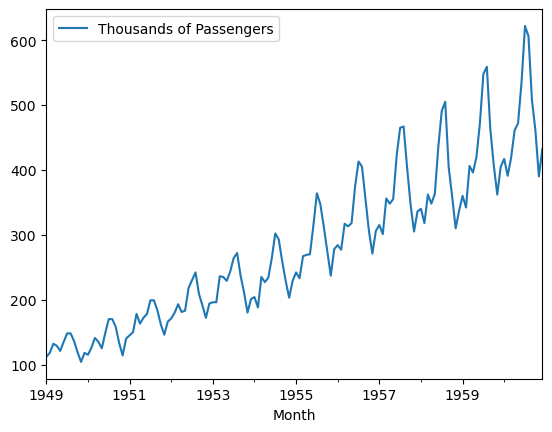

In [96]:
df.plot()

In [97]:
# Trend and seasonlity seems to exist 

## Test for Stationarity with the Augmented Dickey-Fuller Test

The Augmented Dickey-Fuller test evaluates whether the time series contains a unit root.

### Hypotheses

- **Null hypothesis:** The series is non-stationary.
- **Alternative hypothesis:** The series is stationary.

A p-value less than or equal to 0.05 provides evidence to reject the null hypothesis.

In [98]:
from statsmodels.tsa.stattools import adfuller

### Reusable Stationarity Test Function

A reusable function is created to calculate and display:

- ADF test statistic
- P-value
- Stationarity conclusion

This function is applied to the original and differenced series.

In [99]:
def adf_fuller(series):
    result=adfuller(series)
    print(f"ADF Statistics Value: {result[0]}")
    print(f"P-Value: {result[1]}")
    if result[1] <= 0.05:
        print('Reject NULL Hypothesis. Time Series is stationary and does not have unit root')
    else:
        print('Not enough evidence to reject NULL Hypothesis. Time Series is not stationary and has a unit root')

### Stationarity of the Original Series

The ADF test is first applied to the original passenger series.

The high p-value indicates that the original data is non-stationary, which is consistent with the visible trend and seasonal pattern.

In [100]:
adf_fuller(df['Thousands of Passengers'])

ADF Statistics Value: 0.8153688792060523
P-Value: 0.991880243437641
Not enough evidence to reject NULL Hypothesis. Time Series is not stationary and has a unit root


## First-Order Differencing

First-order differencing calculates the change between consecutive months.

This transformation helps remove trend by focusing on month-to-month changes rather than the original passenger levels.

In [101]:
df['passenger_differencing']=df['Thousands of Passengers'] - df['Thousands of Passengers'].shift(1)

In [102]:
df.head()

,Thousands of Passengers,passenger_differencing
Month,,
1949-01-01,112.0,NaN
1949-02-01,118.0,6.0
1949-03-01,132.0,14.0
1949-04-01,129.0,-3.0
1949-05-01,121.0,-8.0


In [103]:
adf_fuller(df['passenger_differencing'].dropna())

ADF Statistics Value: -2.829266824169988
P-Value: 0.05421329028382705
Not enough evidence to reject NULL Hypothesis. Time Series is not stationary and has a unit root


## Second-Order Differencing

A second differencing step is applied to the first-differenced series.

This transformation removes additional non-stationary structure and produces a series that passes the ADF stationarity test.

In [104]:
df['passenger_second_differencing']=df['passenger_differencing'] - df['passenger_differencing'].shift(1)

In [105]:
df.head()

,Thousands of Passengers,passenger_differencing,passenger_second_differencing
Month,,,
1949-01-01,112.0,NaN,NaN
1949-02-01,118.0,6.0,NaN
1949-03-01,132.0,14.0,8.0
1949-04-01,129.0,-3.0,-17.0
1949-05-01,121.0,-8.0,-5.0


In [106]:
adf_fuller(df['passenger_second_differencing'].dropna())

ADF Statistics Value: -16.3842315424685
P-Value: 2.73289185001424e-29
Reject NULL Hypothesis. Time Series is stationary and does not have unit root


## Seasonal Differencing

Because the data is monthly and displays an annual seasonal pattern, seasonal differencing is performed using a lag of 12 months.

Seasonal differencing compares each month with the same month from the previous year, helping remove recurring yearly patterns.

In [107]:
df['passenger_12_differencing']=df['Thousands of Passengers'] - df['Thousands of Passengers'].shift(12)

In [108]:
df.head()

,Thousands of Passengers,passenger_differencing,passenger_second_differencing,passenger_12_differencing
Month,,,,
1949-01-01,112.0,NaN,NaN,NaN
1949-02-01,118.0,6.0,NaN,NaN
1949-03-01,132.0,14.0,8.0,NaN
1949-04-01,129.0,-3.0,-17.0,NaN
1949-05-01,121.0,-8.0,-5.0,NaN


### Stationarity after Seasonal Differencing

The ADF test confirms that the seasonally differenced series is stationary.

This supports the use of seasonal forecasting models such as SARIMAX.

In [109]:
adf_fuller(df['passenger_12_differencing'].dropna())

ADF Statistics Value: -3.3830207264924805
P-Value: 0.011551493085514978
Reject NULL Hypothesis. Time Series is stationary and does not have unit root


## ACF and PACF Analysis

Autocorrelation and partial autocorrelation plots are used to guide ARIMA parameter selection.

- The **ACF plot** helps identify the moving-average order, `q`.
- The **PACF plot** helps identify the autoregressive order, `p`.
- The number of differencing operations determines `d`.

For seasonal models, similar reasoning is applied to seasonal parameters.

In [110]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

### Autocorrelation of the Differenced Series

The ACF plot is examined to identify significant lag relationships in the transformed time series.

Large spikes outside the confidence interval indicate lags that may contribute to the moving-average component.

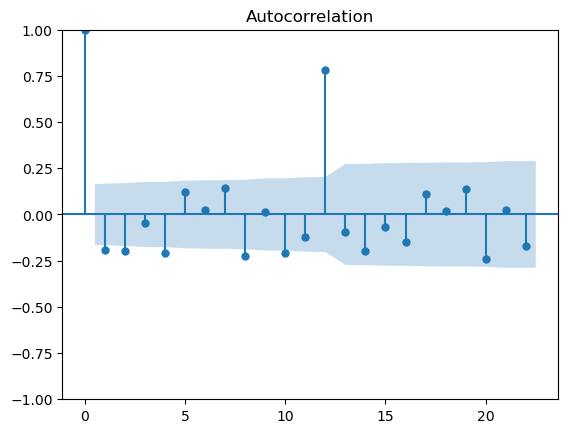

In [111]:
acf=plot_acf(df['passenger_second_differencing'].dropna())

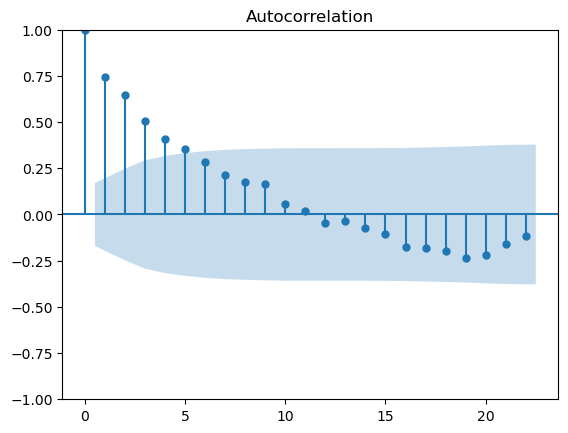

In [112]:
acf12=plot_acf(df['passenger_12_differencing'].dropna())

### Partial Autocorrelation of the Differenced Series

The PACF plot measures the direct relationship between the series and each lag after controlling for shorter lags.

This helps estimate the autoregressive order for the ARIMA and SARIMAX models.

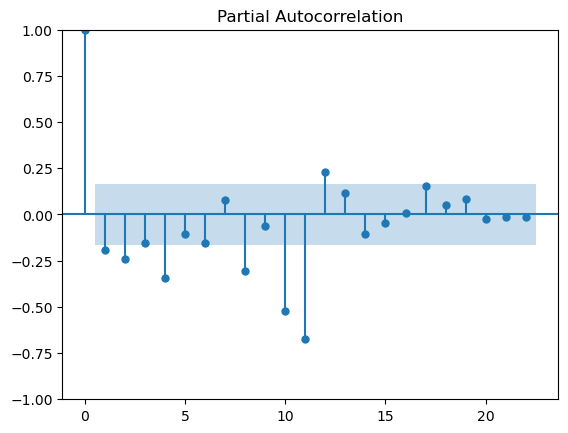

In [113]:
acf=plot_pacf(df['passenger_second_differencing'].dropna())

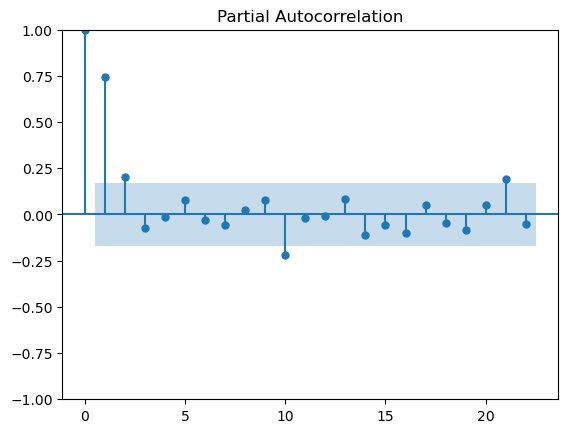

In [114]:
pacf12=plot_pacf(df['passenger_12_differencing'].dropna())

In [115]:
#p value first 2 then upto 10

In [116]:
df.head()

,Thousands of Passengers,passenger_differencing,passenger_second_differencing,passenger_12_differencing
Month,,,,
1949-01-01,112.0,NaN,NaN,NaN
1949-02-01,118.0,6.0,NaN,NaN
1949-03-01,132.0,14.0,8.0,NaN
1949-04-01,129.0,-3.0,-17.0,NaN
1949-05-01,121.0,-8.0,-5.0,NaN


In [117]:
df.tail()

,Thousands of Passengers,passenger_differencing,passenger_second_differencing,passenger_12_differencing
Month,,,,
1960-08-01,606.0,-16.0,-103.0,47.0
1960-09-01,508.0,-98.0,-82.0,45.0
1960-10-01,461.0,-47.0,51.0,54.0
1960-11-01,390.0,-71.0,-24.0,28.0
1960-12-01,432.0,42.0,113.0,27.0


## Split the Time Series into Training and Test Sets

The earlier observations are used for model training, while the later observations are reserved for out-of-sample evaluation.

Unlike random train-test splitting, time-series data must remain in chronological order to prevent future information from leaking into the training period.

In [118]:
from datetime import datetime, timedelta
train_dataset_end=datetime(1955,12,1)
test_dataset_end=datetime(1960,12,1)

### Training and Evaluation Periods

The dataset is divided as follows:

- Training period: January 1949 through December 1955
- Test period: January 1956 through December 1960

The test period is used to evaluate how well the models forecast unseen future observations.

In [119]:
train_data=df[:train_dataset_end]
test_data=df[train_dataset_end+timedelta(days=1):test_dataset_end]

In [120]:
train_data.shape

(84, 4)

In [121]:
test_data.shape

(60, 4)

In [122]:
test_data.head()

,Thousands of Passengers,passenger_differencing,passenger_second_differencing,passenger_12_differencing
Month,,,,
1956-01-01,284.0,6.0,-35.0,42.0
1956-02-01,277.0,-7.0,-13.0,44.0
1956-03-01,317.0,40.0,47.0,50.0
1956-04-01,313.0,-4.0,-44.0,44.0
1956-05-01,318.0,5.0,9.0,48.0


In [123]:
test_data.index

DatetimeIndex(['1956-01-01', '1956-02-01', '1956-03-01', '1956-04-01',
               '1956-05-01', '1956-06-01', '1956-07-01', '1956-08-01',
               '1956-09-01', '1956-10-01', '1956-11-01', '1956-12-01',
               '1957-01-01', '1957-02-01', '1957-03-01', '1957-04-01',
               '1957-05-01', '1957-06-01', '1957-07-01', '1957-08-01',
               '1957-09-01', '1957-10-01', '1957-11-01', '1957-12-01',
               '1958-01-01', '1958-02-01', '1958-03-01', '1958-04-01',
               '1958-05-01', '1958-06-01', '1958-07-01', '1958-08-01',
               '1958-09-01', '1958-10-01', '1958-11-01', '1958-12-01',
               '1959-01-01', '1959-02-01', '1959-03-01', '1959-04-01',
               '1959-05-01', '1959-06-01', '1959-07-01', '1959-08-01',
               '1959-09-01', '1959-10-01', '1959-11-01', '1959-12-01',
               '1960-01-01', '1960-02-01', '1960-03-01', '1960-04-01',
               '1960-05-01', '1960-06-01', '1960-07-01', '1960-08-01',
      

## Define the Forecast Horizon

The prediction period begins with the first month of the test set and ends with the final test observation.

The models will generate forecasts across the entire held-out period.

In [124]:
##prediction
pred_start_date=test_data.index[0]
pred_end_date=test_data.index[-1]

## ARIMA Forecasting Model

ARIMA combines three components:

- `p`: autoregressive order
- `d`: differencing order
- `q`: moving-average order

The first model uses an order of `(10, 2, 0)`, meaning:

- 10 autoregressive lags
- Second-order differencing
- No moving-average terms

The model is trained using only the training period.

In [125]:
from statsmodels.tsa.arima.model import ARIMA

In [126]:
model_arima_pd=ARIMA(train_data['Thousands of Passengers'],order=(10,2,0))

/Users/shankariseethalaksmimohanakrishnan/miniforge3/envs/ml_env/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/shankariseethalaksmimohanakrishnan/miniforge3/envs/ml_env/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/shankariseethalaksmimohanakrishnan/miniforge3/envs/ml_env/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


### Fit the ARIMA Model

The ARIMA model parameters are estimated using maximum likelihood.

The summary output includes:

- Estimated coefficients
- Statistical significance
- AIC and BIC
- Residual diagnostics
- Model fit statistics

In [127]:
model_arima_pd_fit=model_arima_pd.fit()

In [128]:
model_arima_pd_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                  SARIMAX Results                                  
===================================================================================
Dep. Variable:     Thousands of Passengers   No. Observations:                   84
Model:                     ARIMA(10, 2, 0)   Log Likelihood                -357.239
Date:                     Thu, 30 Jul 2026   AIC                            736.477
Time:                             22:28:18   BIC                            762.951
Sample:                         01-01-1949   HQIC                           747.106
                              - 12-01-1955                                         
Covariance Type:                       opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5166      0.121     -4.262      0.000      -0.754      -0.279
ar.L2         -0.7204      0.121     -5.940      0.000      -0.958      -0.483
ar.L3         -0.4857      0.125     -3.876      0.000      -0.731      -0.240
ar.L4         -0.7505      0.129     -5.819      0.000      -1.003      -0.498
ar.L5         -0.5062      0.169     -2.991      0.003      -0.838      -0.175
ar.L6         -0.5200      0.141     -3.683      0.000      -0.797      -0.243
ar.L7         -0.3051      0.143     -2.127      0.033      -0.586      -0.024
ar.L8         -0.5939      0.155     -3.833      0.000      -0.898      -0.290
ar.L9         -0.2963      0.132     -2.241      0.025      -0.555      -0.037
ar.L10        -0.4825      0.110     -4.376      0.000      -0.699      -0.266
sigma2       336.0939     66.064      5.087      0.000     206.612     465.576
===================================================================================
Ljung-Box (L1) (Q):                  10.86   Jarque-Bera (JB):                 1.24
Prob(Q):                              0.00   Prob(JB):                         0.54
Heteroskedasticity (H):               2.85   Skew:                             0.24
Prob(H) (two-sided):                  0.01   Kurtosis:                         2.64
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Generate ARIMA Forecasts

The fitted ARIMA model produces predictions for the complete test period.

These forecasts are then compared with the actual passenger observations.

In [129]:
pred=model_arima_pd_fit.predict(start=pred_start_date, end=pred_end_date)
pred[:10]

1956-01-01    300.183613
1956-02-01    309.478356
1956-03-01    316.443015
1956-04-01    307.827544
1956-05-01    318.544233
1956-06-01    348.922082
1956-07-01    366.020288
1956-08-01    346.567534
1956-09-01    332.120968
1956-10-01    307.734754
Freq: MS, Name: predicted_mean, dtype: float64

### Calculate Forecast Residuals

Residuals represent the difference between actual and predicted values.

A strong forecasting model should produce residuals that:

- Are centered around zero
- Show no remaining time pattern
- Have approximately constant variance

In [130]:
residuals=test_data['Thousands of Passengers']-pred
residuals[:10]

Month
1956-01-01   -16.183613
1956-02-01   -32.478356
1956-03-01     0.556985
1956-04-01     5.172456
1956-05-01    -0.544233
1956-06-01    25.077918
1956-07-01    46.979712
1956-08-01    58.432466
1956-09-01    22.879032
1956-10-01    -1.734754
dtype: float64

### Inspect the ARIMA Residual Distribution

The residual density plot is used to evaluate whether the model errors are approximately centered and symmetrically distributed.

Strong systematic patterns in residuals may indicate that the model has not captured all relevant structure.

<Axes: ylabel='Density'>

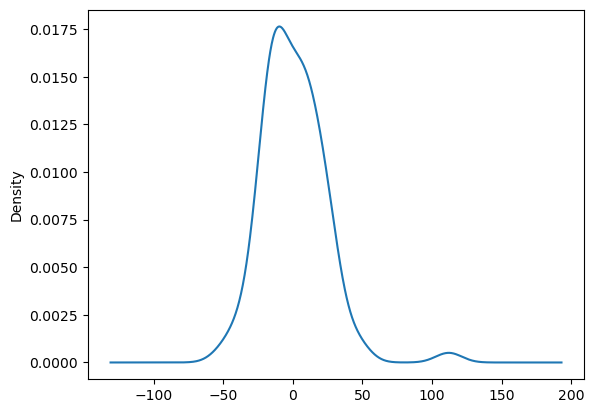

In [131]:
model_arima_pd_fit.resid.plot(kind='kde')

### Compare Actual and ARIMA-Predicted Values

ARIMA forecasts are added to the test dataframe and plotted against the actual passenger counts.

This visualization shows how closely the non-seasonal ARIMA model follows the observed trend and seasonal movement.

In [132]:
test_data['Predicted_ARIMA']=pred

/var/folders/99/nqyz4s796bx09s6p71mvxd5h0000gn/T/ipykernel_6694/95659616.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['Predicted_ARIMA']=pred


In [133]:
test_data.head()

,Thousands of Passengers,passenger_differencing,passenger_second_differencing,passenger_12_differencing,Predicted_ARIMA
Month,,,,,
1956-01-01,284.0,6.0,-35.0,42.0,300.183613
1956-02-01,277.0,-7.0,-13.0,44.0,309.478356
1956-03-01,317.0,40.0,47.0,50.0,316.443015
1956-04-01,313.0,-4.0,-44.0,44.0,307.827544
1956-05-01,318.0,5.0,9.0,48.0,318.544233


<Axes: xlabel='Month'>

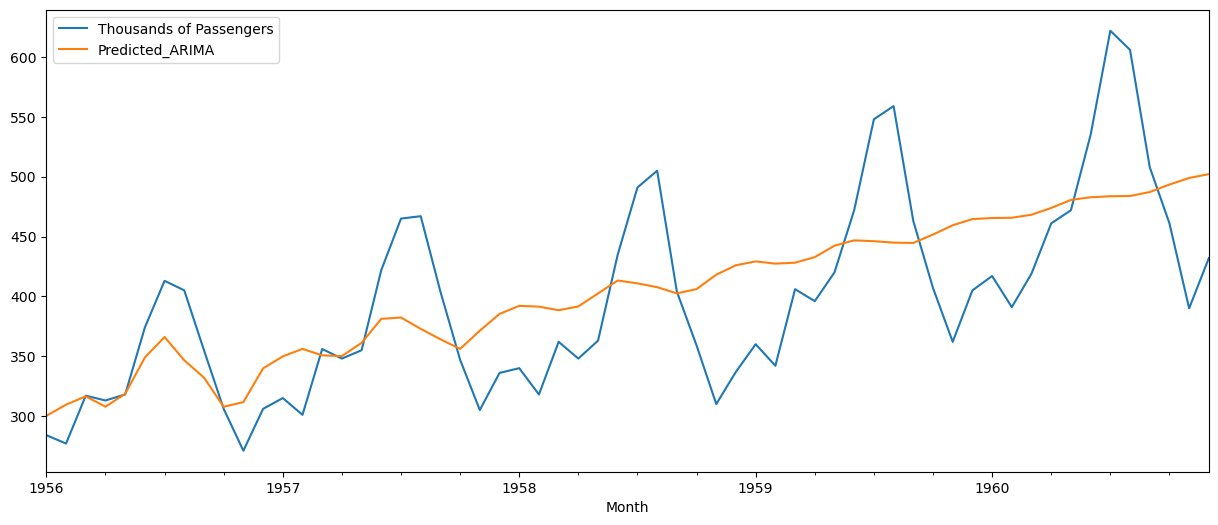

In [134]:
test_data[['Thousands of Passengers','Predicted_ARIMA']].plot(figsize=(15,6))

## ARIMA Model with Autoregressive and Moving-Average Terms

A second ARIMA specification is created using both autoregressive and moving-average components.

The selected order is `(10, 2, 12)`:

- `p = 10`
- `d = 2`
- `q = 12`

This higher-order model is intended to capture more complex lag relationships.

In [135]:
model_arima_pdq=ARIMA(train_data['Thousands of Passengers'],order=(10,2,12))

/Users/shankariseethalaksmimohanakrishnan/miniforge3/envs/ml_env/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/shankariseethalaksmimohanakrishnan/miniforge3/envs/ml_env/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/shankariseethalaksmimohanakrishnan/miniforge3/envs/ml_env/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [136]:
model_arima_pdq_fit=model_arima_pdq.fit()

/Users/shankariseethalaksmimohanakrishnan/miniforge3/envs/ml_env/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/shankariseethalaksmimohanakrishnan/miniforge3/envs/ml_env/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [137]:
model_arima_pdq_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                  SARIMAX Results                                  
===================================================================================
Dep. Variable:     Thousands of Passengers   No. Observations:                   84
Model:                    ARIMA(10, 2, 12)   Log Likelihood                -307.732
Date:                     Thu, 30 Jul 2026   AIC                            661.464
Time:                             22:28:24   BIC                            716.818
Sample:                         01-01-1949   HQIC                           683.688
                              - 12-01-1955                                         
Covariance Type:                       opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0467      0.115      0.408      0.683      -0.178       0.271
ar.L2         -1.0428      0.083    -12.490      0.000      -1.206      -0.879
ar.L3          0.0885      0.139      0.638      0.523      -0.183       0.360
ar.L4         -1.0256      0.131     -7.834      0.000      -1.282      -0.769
ar.L5          0.0656      0.155      0.423      0.672      -0.239       0.370
ar.L6         -0.9858      0.143     -6.877      0.000      -1.267      -0.705
ar.L7          0.0174      0.142      0.122      0.903      -0.261       0.296
ar.L8         -0.9822      0.123     -8.017      0.000      -1.222      -0.742
ar.L9         -0.0069      0.095     -0.073      0.942      -0.193       0.179
ar.L10        -0.9389      0.085    -11.079      0.000      -1.105      -0.773
ma.L1         -1.2856      0.254     -5.060      0.000      -1.784      -0.788
ma.L2          1.2390      0.358      3.458      0.001       0.537       1.941
ma.L3         -1.4408      0.436     -3.305      0.001      -2.295      -0.586
ma.L4          1.3748      0.506      2.716      0.007       0.383       2.367
ma.L5         -1.2152      0.574     -2.118      0.034      -2.340      -0.091
ma.L6          1.0822      0.660      1.641      0.101      -0.211       2.375
ma.L7         -1.0693      0.714     -1.497      0.134      -2.470       0.331
ma.L8          0.8854      0.819      1.081      0.280      -0.720       2.490
ma.L9         -0.7847      0.737     -1.065      0.287      -2.228       0.659
ma.L10         0.5232      0.601      0.870      0.384      -0.655       1.702
ma.L11        -0.4131      0.455     -0.908      0.364      -1.305       0.478
ma.L12         0.1335      0.273      0.489      0.625      -0.402       0.669
sigma2        77.2116     16.196      4.767      0.000      45.469     108.954
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 4.73
Prob(Q):                              0.99   Prob(JB):                         0.09
Heteroskedasticity (H):               2.12   Skew:                             0.59
Prob(H) (two-sided):                  0.06   Kurtosis:                         2.89
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Generate Forecasts from the ARIMA `(p,d,q)` Model

The second ARIMA model generates predictions across the same test horizon.

Its results can be compared with the first ARIMA specification to evaluate whether the moving-average terms improve forecasting performance.

In [138]:
pdq_pred=model_arima_pdq_fit.predict(start=pred_start_date, end=pred_end_date)
pdq_pred[:10]

1956-01-01    283.251636
1956-02-01    269.508803
1956-03-01    295.175273
1956-04-01    298.579210
1956-05-01    299.102174
1956-06-01    345.356409
1956-07-01    388.488282
1956-08-01    371.888161
1956-09-01    340.071916
1956-10-01    302.907856
Freq: MS, Name: predicted_mean, dtype: float64

In [139]:
pdq_res=test_data['Thousands of Passengers']-pdq_pred
pdq_res[:10]

Month
1956-01-01     0.748364
1956-02-01     7.491197
1956-03-01    21.824727
1956-04-01    14.420790
1956-05-01    18.897826
1956-06-01    28.643591
1956-07-01    24.511718
1956-08-01    33.111839
1956-09-01    14.928084
1956-10-01     3.092144
dtype: float64

<Axes: ylabel='Density'>

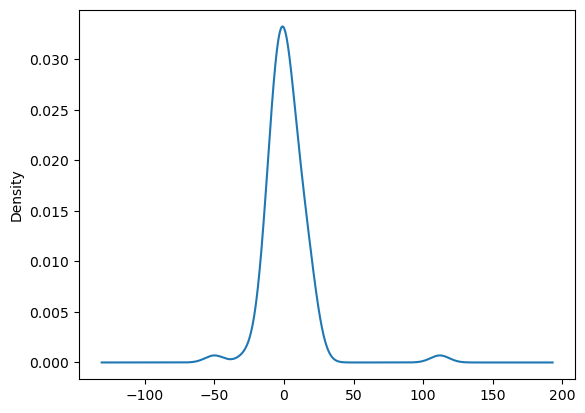

In [140]:
model_arima_pdq_fit.resid.plot(kind='kde')

In [141]:
test_data['Predicted_ARIMA_PDQ']=pdq_pred
test_data.head()

/var/folders/99/nqyz4s796bx09s6p71mvxd5h0000gn/T/ipykernel_6694/2220166384.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['Predicted_ARIMA_PDQ']=pdq_pred


,Thousands of Passengers,passenger_differencing,passenger_second_differencing,passenger_12_differencing,Predicted_ARIMA,Predicted_ARIMA_PDQ
Month,,,,,,
1956-01-01,284.0,6.0,-35.0,42.0,300.183613,283.251636
1956-02-01,277.0,-7.0,-13.0,44.0,309.478356,269.508803
1956-03-01,317.0,40.0,47.0,50.0,316.443015,295.175273
1956-04-01,313.0,-4.0,-44.0,44.0,307.827544,298.579210
1956-05-01,318.0,5.0,9.0,48.0,318.544233,299.102174


<Axes: xlabel='Month'>

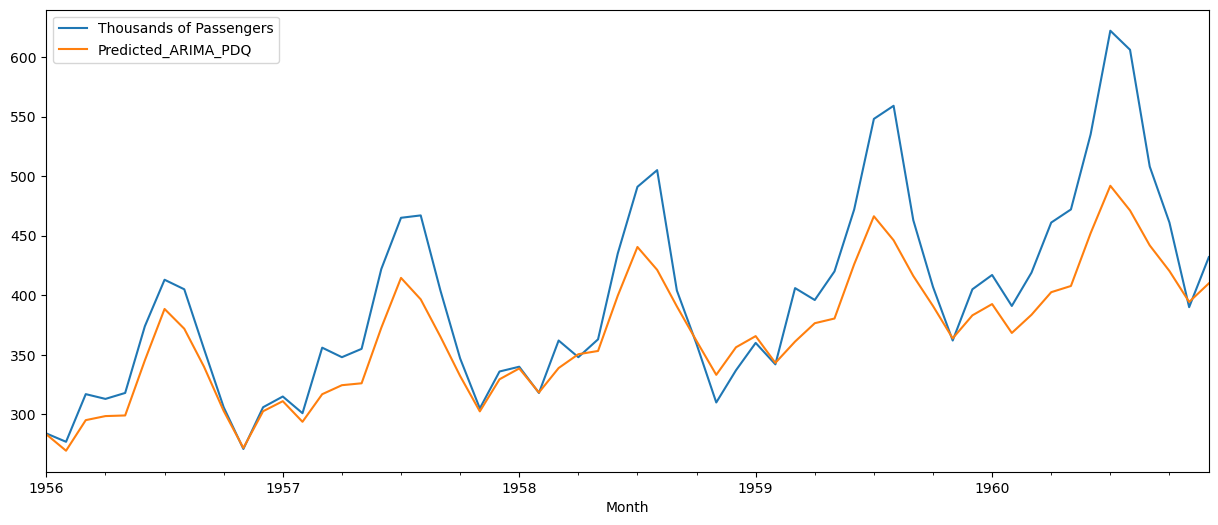

In [142]:
test_data[['Thousands of Passengers','Predicted_ARIMA_PDQ']].plot(figsize=(15,6))


## SARIMAX Forecasting Model

SARIMAX extends ARIMA by explicitly modeling seasonal behavior.

The seasonal order is written as:

`(P, D, Q, s)`

where:

- `P` is the seasonal autoregressive order
- `D` is the seasonal differencing order
- `Q` is the seasonal moving-average order
- `s` is the seasonal period

For monthly airline data, `s = 12` represents annual seasonality.

In [143]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

### Configure the Seasonal Model

The SARIMAX model uses:

- Non-seasonal order: `(3, 0, 5)`
- Seasonal order: `(0, 1, 0, 12)`

The seasonal differencing term allows the model to capture the recurring twelve-month passenger pattern.

In [144]:
model_sarimax=SARIMAX(train_data['Thousands of Passengers'],order=(3,0,5),seasonal_order=(0,1,0,12))

/Users/shankariseethalaksmimohanakrishnan/miniforge3/envs/ml_env/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/shankariseethalaksmimohanakrishnan/miniforge3/envs/ml_env/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


### Fit the SARIMAX Model

The SARIMAX model is estimated using the training data.

The model summary provides:

- Seasonal and non-seasonal parameters
- Coefficient estimates
- Information criteria
- Residual diagnostics
- Statistical significance results

In [145]:
model_SARIMAX_fit=model_sarimax.fit()

/Users/shankariseethalaksmimohanakrishnan/miniforge3/envs/ml_env/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [146]:
model_SARIMAX_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:             Thousands of Passengers   No. Observations:                   84
Model:             SARIMAX(3, 0, 5)x(0, 1, [], 12)   Log Likelihood                -265.241
Date:                             Thu, 30 Jul 2026   AIC                            548.481
Time:                                     22:28:28   BIC                            568.971
Sample:                                 01-01-1949   HQIC                           556.638
                                      - 12-01-1955                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5998      0.940      0.638      0.523      -1.242       2.442
ar.L2          0.8315      0.233      3.575      0.000       0.376       1.287
ar.L3         -0.4543      0.896     -0.507      0.612      -2.211       1.302
ma.L1          0.1822      1.176      0.155      0.877      -2.123       2.487
ma.L2         -0.5359      1.275     -0.420      0.674      -3.035       1.963
ma.L3         -0.0986      0.388     -0.254      0.800      -0.859       0.662
ma.L4         -0.1270      0.342     -0.371      0.710      -0.797       0.543
ma.L5          0.2471      0.360      0.687      0.492      -0.458       0.952
sigma2        87.7047     82.399      1.064      0.287     -73.794     249.204
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 2.68
Prob(Q):                              0.88   Prob(JB):                         0.26
Heteroskedasticity (H):               2.05   Skew:                             0.46
Prob(H) (two-sided):                  0.09   Kurtosis:                         2.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [147]:
pred_sarimax=model_SARIMAX_fit.predict(pred_start_date, pred_end_date)
pred_sarimax[:10]

1956-01-01    286.194323
1956-02-01    281.283649
1956-03-01    309.927224
1956-04-01    310.689415
1956-05-01    311.342780
1956-06-01    354.960787
1956-07-01    403.405991
1956-08-01    385.081539
1956-09-01    349.453669
1956-10-01    310.227804
Freq: MS, Name: predicted_mean, dtype: float64

### Evaluate SARIMAX Residuals

The forecast residuals are calculated to measure the difference between actual passenger counts and SARIMAX predictions.

Smaller and less structured residuals indicate stronger forecasting performance.

In [148]:
residuals=test_data['Thousands of Passengers']-pred_sarimax
residuals[:10]

Month
1956-01-01    -2.194323
1956-02-01    -4.283649
1956-03-01     7.072776
1956-04-01     2.310585
1956-05-01     6.657220
1956-06-01    19.039213
1956-07-01     9.594009
1956-08-01    19.918461
1956-09-01     5.546331
1956-10-01    -4.227804
dtype: float64

<Axes: ylabel='Density'>

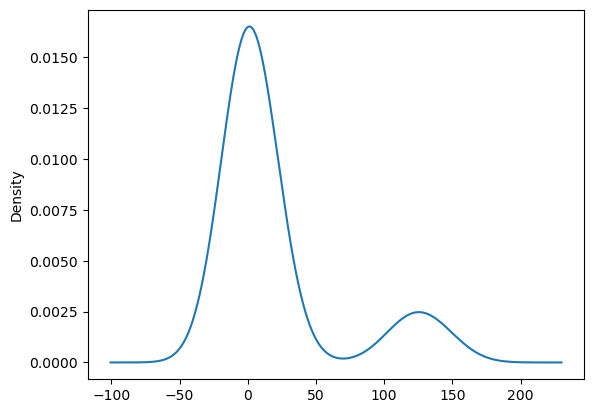

In [149]:
model_SARIMAX_fit.resid.plot(kind='kde')

### Compare Actual and SARIMAX-Predicted Values

The seasonal forecasts are added to the test dataset and plotted alongside the actual passenger series.

This makes it easier to visually assess how well the model captures both the long-term trend and annual seasonal peaks.

In [150]:
test_data['predicteded_SARIMAX']=pred_sarimax

/var/folders/99/nqyz4s796bx09s6p71mvxd5h0000gn/T/ipykernel_6694/2107337993.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['predicteded_SARIMAX']=pred_sarimax


In [151]:
test_data.head()

,Thousands of Passengers,passenger_differencing,passenger_second_differencing,passenger_12_differencing,Predicted_ARIMA,Predicted_ARIMA_PDQ,predicteded_SARIMAX
Month,,,,,,,
1956-01-01,284.0,6.0,-35.0,42.0,300.183613,283.251636,286.194323
1956-02-01,277.0,-7.0,-13.0,44.0,309.478356,269.508803,281.283649
1956-03-01,317.0,40.0,47.0,50.0,316.443015,295.175273,309.927224
1956-04-01,313.0,-4.0,-44.0,44.0,307.827544,298.579210,310.689415
1956-05-01,318.0,5.0,9.0,48.0,318.544233,299.102174,311.342780


<Axes: xlabel='Month'>

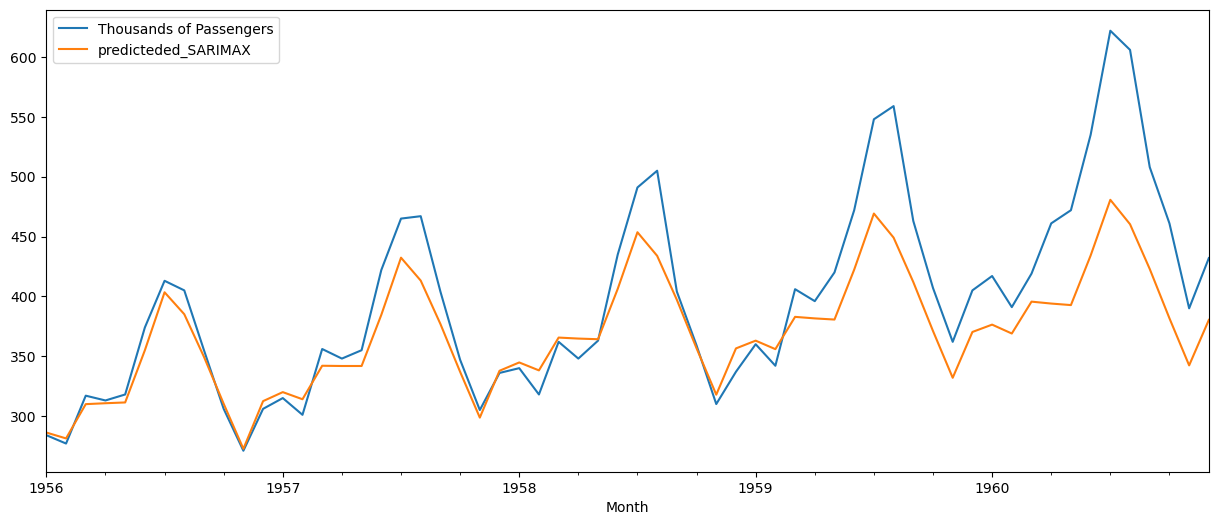

In [152]:
test_data[['Thousands of Passengers','predicteded_SARIMAX']].plot(figsize=(15,6))

## Compare ARIMA and SARIMAX Forecasts

The final visualization compares:

- Actual passenger counts
- ARIMA predictions
- SARIMAX predictions

This comparison highlights the importance of modeling seasonality explicitly when the data contains strong annual patterns.

<Axes: xlabel='Month'>

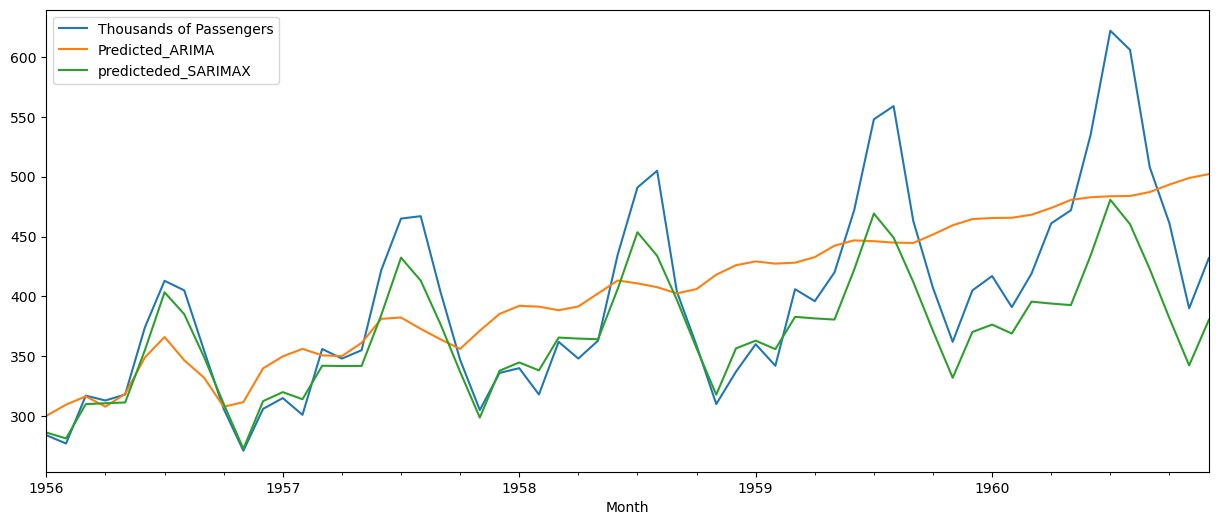

In [153]:
test_data[['Thousands of Passengers','Predicted_ARIMA','predicteded_SARIMAX']].plot(figsize=(15,6))

In [155]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_forecast(actual, predicted, model_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    return pd.DataFrame({
        'Model': [model_name],
        'MAE': [mae],
        'RMSE': [rmse]
    })

arima_metrics = evaluate_forecast(
    test_data['Thousands of Passengers'],
    test_data['Predicted_ARIMA'],
    'ARIMA'
)

sarimax_metrics = evaluate_forecast(
    test_data['Thousands of Passengers'],
    test_data['predicteded_SARIMAX'],
    'SARIMAX'
)

model_comparison = pd.concat(
    [arima_metrics, sarimax_metrics],
    ignore_index=True
)

model_comparison

,Model,MAE,RMSE
0,ARIMA,48.100291,59.303969
1,SARIMAX,31.628043,46.364757
